# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import matplotlib.patches as patches

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from scipy.stats import spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests
from collections import Counter

import gseapy as gp
import os

# DATA

## de novo variant & attention score

In [ ]:
dnv = pd.read_feather('/path/to/data/variant.csv')
label = pd.read_csv("/path/to/data/label.csv")

In [ ]:
ATTN_ROOT = "/path/to/attn"

# DNABERT
zs_dnabert_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/dnabert_zs_attn.csv")
ft_dnabert_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_ncre_attn.csv")
ft_dnabert_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_bend_attn.csv")
ft_dnabert_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_clinvar_attn.csv")
ft_dnabert_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_gnomad_attn.csv")

# DNABERT2
zs_dnabert2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/dnabert2_zs_attn.csv")
ft_dnabert2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_ncre_attn.csv")
ft_dnabert2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_bend_attn.csv")
ft_dnabert2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_clinvar_attn.csv")
ft_dnabert2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_gnomad_attn.csv")

# NTv2
zs_ntv2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/ntv2_zs_attn.csv")
ft_ntv2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_ncre_attn.csv")
ft_ntv2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_bend_attn.csv")
ft_ntv2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_clinvar_attn.csv")
ft_ntv2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_gnomad_attn.csv")

# NTv3
zs_ntv3_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/ntv3_zs_attn.csv")
ft_ntv3_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_ncre_attn.csv")
ft_ntv3_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_bend_attn.csv")
ft_ntv3_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_clinvar_attn.csv")
ft_ntv3_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_gnomad_attn.csv")

# HyenaDNA
zs_hyena_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/hyenadna_zs_attn.csv")
ft_hyena_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_ncre_attn.csv")
ft_hyena_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_bend_attn.csv")
ft_hyena_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_clinvar_attn.csv")
ft_hyena_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_gnomad_attn.csv")

# evo2
zs_evo2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/evo2_zs_attn.csv")
ft_evo2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_ncre_attn.csv")
ft_evo2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_bend_attn.csv")
ft_evo2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_clinvar_attn.csv")
ft_evo2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_gnomad_attn.csv")

# PhyloGPN
zs_phylogpn_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/phylogpn_zs_attn.csv")
ft_phylogpn_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_ncre_attn.csv")
ft_phylogpn_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_bend_attn.csv")
ft_phylogpn_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_clinvar_attn.csv")
ft_phylogpn_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_gnomad_attn.csv")

model_tasks_attn = {
    "DNABERT":  {"ZS": zs_dnabert_attn,  "NCRE": ft_dnabert_ncre_attn,  "BEND": ft_dnabert_bend_attn,  "ClinVar": ft_dnabert_clinvar_attn,  "gnomAD": ft_dnabert_gnomad_attn},
    "DNABERT2": {"ZS": zs_dnabert2_attn, "NCRE": ft_dnabert2_ncre_attn, "BEND": ft_dnabert2_bend_attn, "ClinVar": ft_dnabert2_clinvar_attn, "gnomAD": ft_dnabert2_gnomad_attn},
    "NTv2":     {"ZS": zs_ntv2_attn,     "NCRE": ft_ntv2_ncre_attn,     "BEND": ft_ntv2_bend_attn,     "ClinVar": ft_ntv2_clinvar_attn,     "gnomAD": ft_ntv2_gnomad_attn},
    "NTv3":     {"ZS": zs_ntv3_attn,     "NCRE": ft_ntv3_ncre_attn,     "BEND": ft_ntv3_bend_attn,     "ClinVar": ft_ntv3_clinvar_attn,     "gnomAD": ft_ntv3_gnomad_attn},
    "HyenaDNA": {"ZS": zs_hyena_attn,    "NCRE": ft_hyena_ncre_attn,    "BEND": ft_hyena_bend_attn,    "ClinVar": ft_hyena_clinvar_attn,    "gnomAD": ft_hyena_gnomad_attn},
    "Evo 2": {"ZS": zs_evo2_attn,    "NCRE": ft_evo2_ncre_attn,    "BEND": ft_evo2_bend_attn,    "ClinVar": ft_evo2_clinvar_attn,    "gnomAD": ft_evo2_gnomad_attn},
    "PhyloGPN": {"ZS": zs_phylogpn_attn, "NCRE": ft_phylogpn_ncre_attn, "BEND": ft_phylogpn_bend_attn, "ClinVar": ft_phylogpn_clinvar_attn, "gnomAD": ft_phylogpn_gnomad_attn},
}

In [ ]:
tasks  = ['ZS', 'ClinVar', 'gnomAD', 'BEND', 'NCRE']
models = ['DNABERT', 'DNABERT2', 'NTv2', 'NTv3', 'HyenaDNA', 'Evo 2', 'PhyloGPN']

model_labels = {
    'DNABERT'  : 'DNABERT',
    'DNABERT2' : 'DNABERT-2',
    'NTv2'     : 'Nucleotide\nTransformer V2',
    'NTv3'     : 'Nucleotide\nTransformer V3',
    'HyenaDNA' : 'HyenaDNA',
    'Evo 2' : 'Evo 2',
    'PhyloGPN' : 'PhyloGPN',
}

task_labels = {
    'ZS'     : 'Zero-shot',
    'ClinVar': 'ClinVar Missense Variants',
    'gnomAD' : 'gnomAD Variants',
    'BEND'   : 'BEND Non-coding Variants',
    'NCRE'   : 'Non-coding Regulatory Elements',
}

def parse_gene_ratio(overlap_str):
    a, b = overlap_str.split('/')
    return int(a) / int(b)


## severity annotation

In [ ]:
sev = pd.read_feather("/path/to/data/severity_annotation.feather")

# CLR Function

In [8]:
ATTN_COL         = "attention"
CLR_COL          = "attention_clr"
PSEUDOCOUNT      = 1e-12
NORMALIZE_IN_SAMPLE = True
TOP_FRAC         = 0.10

In [ ]:
def clr_transform_by_sample(df):

    df = df.copy()
    df = df.dropna(subset=["vcf_iid", ATTN_COL])
    df["vcf_iid"] = df["vcf_iid"].astype(str)

    df[ATTN_COL] = np.clip(
        pd.to_numeric(df[ATTN_COL], errors="coerce"),
        0,
        None
    )

    def _clr(g):

        x = g[ATTN_COL].to_numpy(dtype=float)

        if NORMALIZE_IN_SAMPLE:
            s = x.sum()
            if (not np.isfinite(s)) or s <= 0:
                g[CLR_COL] = 0.0
                return g
            x = x / s

        x = x + PSEUDOCOUNT
        lx = np.log(x)
        g[CLR_COL] = lx - lx.mean()
        return g

    return df.groupby("vcf_iid", group_keys=False).apply(_clr)

# Preprocessing

In [15]:
# ── ASD ───────────────────────────
asd_samples = set(label[label['Group'] == "Autism"]['vcf_iid'].astype(str))
print(f"# ASD samples: {len(asd_samples)}")

# ── filtering ─────────────────────────────────
sev['vcf_iid'] = sev['vcf_iid'].astype(str)
sev_asd = sev[sev['vcf_iid'].isin(asd_samples)].copy()
print(f"# ASD samples in severity annotation: {len(sev_asd)}")

# ── test set sample ID extraction ──────────────
test_samples = set(zs_dnabert_attn['vcf_iid'].astype(str).unique())
print(f"# test set samples: {len(test_samples)}")

# ── sev_filtered: test set + ASD + sev ───────────────────
sev_filtered = sev_asd[sev_asd['vcf_iid'].isin(test_samples)].copy()
print(f"# final sev_filtered samples: {len(sev_filtered)}")

# ASD samples: 10376
# ASD samples in severity annotation: 7677
# test set samples: 1529
# final sev_filtered samples: 768


In [16]:
# ── gene mapping dnv ───────────────────────────────────
dnv_gene = dnv[dnv['gene_symbol'].notna()][['vcf_iid', 'variant', 'gene_symbol']].copy()
dnv_gene['vcf_iid'] = dnv_gene['vcf_iid'].astype(str)

In [17]:
print(sev_filtered[['ADOS_Total', 'VABS']].isna().sum())
print(f"ADOS samples: {sev_filtered['ADOS_Total'].notna().sum()}")
print(f"VABS samples: {sev_filtered['VABS'].notna().sum()}")

ADOS_Total    370
VABS          214
dtype: int64
ADOS samples: 398
VABS samples: 554


# ADOS CSS

## filtering

In [20]:
# ── ADOS severe samples (≥6) ────────────────────────────────
ados_valid = sev_filtered[sev_filtered['ADOS_Total'].notna()].copy()
ados_top_samples = set(ados_valid[ados_valid['ADOS_Total'] >= 6]['vcf_iid'])
print(f"# ADOS severe samples: {len(ados_top_samples)}")

# ADOS severe samples: 352


In [21]:
gene_list_dict_attn_high_in_ados = {}
gene_list_dict_attn_low_in_ados  = {}

for model, task_dict in model_tasks_attn.items():
    for task, attn_df in task_dict.items():
        col_name = f"{model}_{task}"

        attn_sev = attn_df[attn_df['vcf_iid'].astype(str).isin(ados_top_samples)].copy()
        attn_sev['vcf_iid'] = attn_sev['vcf_iid'].astype(str)

        attn_clr = clr_transform_by_sample(attn_sev)

        n_top = int(np.ceil(len(attn_clr) * TOP_FRAC))
        high = attn_clr.nlargest(n_top, CLR_COL)
        low  = attn_clr.nsmallest(n_top, CLR_COL)

        high_gene = high.merge(dnv_gene, on=['vcf_iid', 'variant'], how='inner')
        low_gene  = low.merge(dnv_gene,  on=['vcf_iid', 'variant'], how='inner')

        def get_recurrent_genes(df):
            variant_cnt = (
                df.groupby('gene_symbol')['variant']
                .nunique()
                .reset_index()
                .rename(columns={'variant': 'variant_cnt'})
            )
            sample_cnt = (
                df.groupby('gene_symbol')['vcf_iid']
                .nunique()
                .reset_index()
                .rename(columns={'vcf_iid': 'sample_cnt'})
            )
            merged = variant_cnt.merge(sample_cnt, on='gene_symbol')
            return merged[
                (merged['variant_cnt'] >= 2) & (merged['sample_cnt'] >= 2)
            ]['gene_symbol'].tolist()

        gene_list_dict_attn_high_in_ados[col_name] = get_recurrent_genes(high_gene)
        gene_list_dict_attn_low_in_ados[col_name]  = get_recurrent_genes(low_gene)

        print(f"{col_name:<22} attn_high={len(gene_list_dict_attn_high_in_ados[col_name]):>4} | "
              f"attn_low={len(gene_list_dict_attn_low_in_ados[col_name]):>4}")

/tmp/ipykernel_54837/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


DNABERT_ZS             attn_high= 119 | attn_low= 164


/tmp/ipykernel_54837/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


DNABERT_NCRE           attn_high= 126 | attn_low= 166


/tmp/ipykernel_54837/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


...

PhyloGPN_BEND          attn_high= 104 | attn_low= 176


/tmp/ipykernel_54837/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


PhyloGPN_ClinVar       attn_high= 115 | attn_low= 163


/tmp/ipykernel_54837/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


PhyloGPN_gnomAD        attn_high= 107 | attn_low= 164


## GSEApy Enrichr

In [22]:
results_enrich_ados_high = {}
results_enrich_ados_low  = {}

for col_name, genes in gene_list_dict_attn_high_in_ados.items():
    if len(genes) == 0:
        print(f"{col_name}: None gene list, skip")
        continue
    try:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets='GO_Biological_Process_2025',
            organism='human',
            outdir=None,
            verbose=False
        )
        results_enrich_ados_high[col_name] = enr.results
        print(f"{col_name}: success, ({len(genes)} gene)")
    except Exception as e:
        print(f"{col_name}: failure → {e}")

for col_name, genes in gene_list_dict_attn_low_in_ados.items():
    if len(genes) == 0:
        print(f"{col_name}: None gene list, skip")
        continue
    try:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets='GO_Biological_Process_2025',
            organism='human',
            outdir=None,
            verbose=False
        )
        results_enrich_ados_low[col_name] = enr.results
        print(f"{col_name}: success, ({len(genes)} gene)")
    except Exception as e:
        print(f"{col_name}: failure → {e}")

DNABERT_ZS: success, (119 gene)
DNABERT_NCRE: success, (126 gene)
DNABERT_BEND: success, (106 gene)
DNABERT_ClinVar: success, (121 gene)
DNABERT_gnomAD: success, (114 gene)
DNABERT2_ZS: success, (106 gene)
DNABERT2_NCRE: success, (121 gene)
DNABERT2_BEND: success, (114 gene)
DNABERT2_ClinVar: success, (108 gene)
DNABERT2_gnomAD: success, (118 gene)
NTv2_ZS: success, (106 gene)
NTv2_NCRE: success, (116 gene)
NTv2_BEND: success, (120 gene)
NTv2_ClinVar: success, (116 gene)
NTv2_gnomAD: success, (120 gene)
NTv3_ZS: success, (117 gene)
NTv3_NCRE: success, (117 gene)
NTv3_BEND: success, (118 gene)
NTv3_ClinVar: success, (107 gene)
NTv3_gnomAD: success, (115 gene)
HyenaDNA_ZS: success, (116 gene)
HyenaDNA_NCRE: success, (122 gene)
HyenaDNA_BEND: success, (121 gene)
HyenaDNA_ClinVar: success, (105 gene)
HyenaDNA_gnomAD: success, (107 gene)
Evo 2_ZS: success, (118 gene)
Evo 2_NCRE: success, (118 gene)
Evo 2_BEND: success, (115 gene)
Evo 2_ClinVar: success, (118 gene)
Evo 2_gnomAD: success, (11

## Visualization

In [ ]:
tasks = ['ZS', 'ClinVar', 'gnomAD', 'BEND', 'NCRE']

target_terms_ados = [
    # ── circuit ──────────────────────────────────────────────                            
    'Neuron Projection Guidance (GO:0097485)',                                           
    'Axon Guidance (GO:0007411)',                                                         
    'Axonogenesis (GO:0007409)',                                                           
    'Nervous System Development (GO:0007399)',                           
    # ── synapse / signaling ───────────────────────────────────
    'Homophilic Cell Adhesion via Plasma Membrane Adhesion Molecules (GO:0007156)',  
    'Regulation of Trans-Synaptic Signaling (GO:0099177)',
    # ADOS specific
    'Neuron Development (GO:0048666)',
    'Neuron Cell-Cell Adhesion (GO:0007158)'
]

0
3.8005618329370043


/tmp/ipykernel_54837/1784654056.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.95])


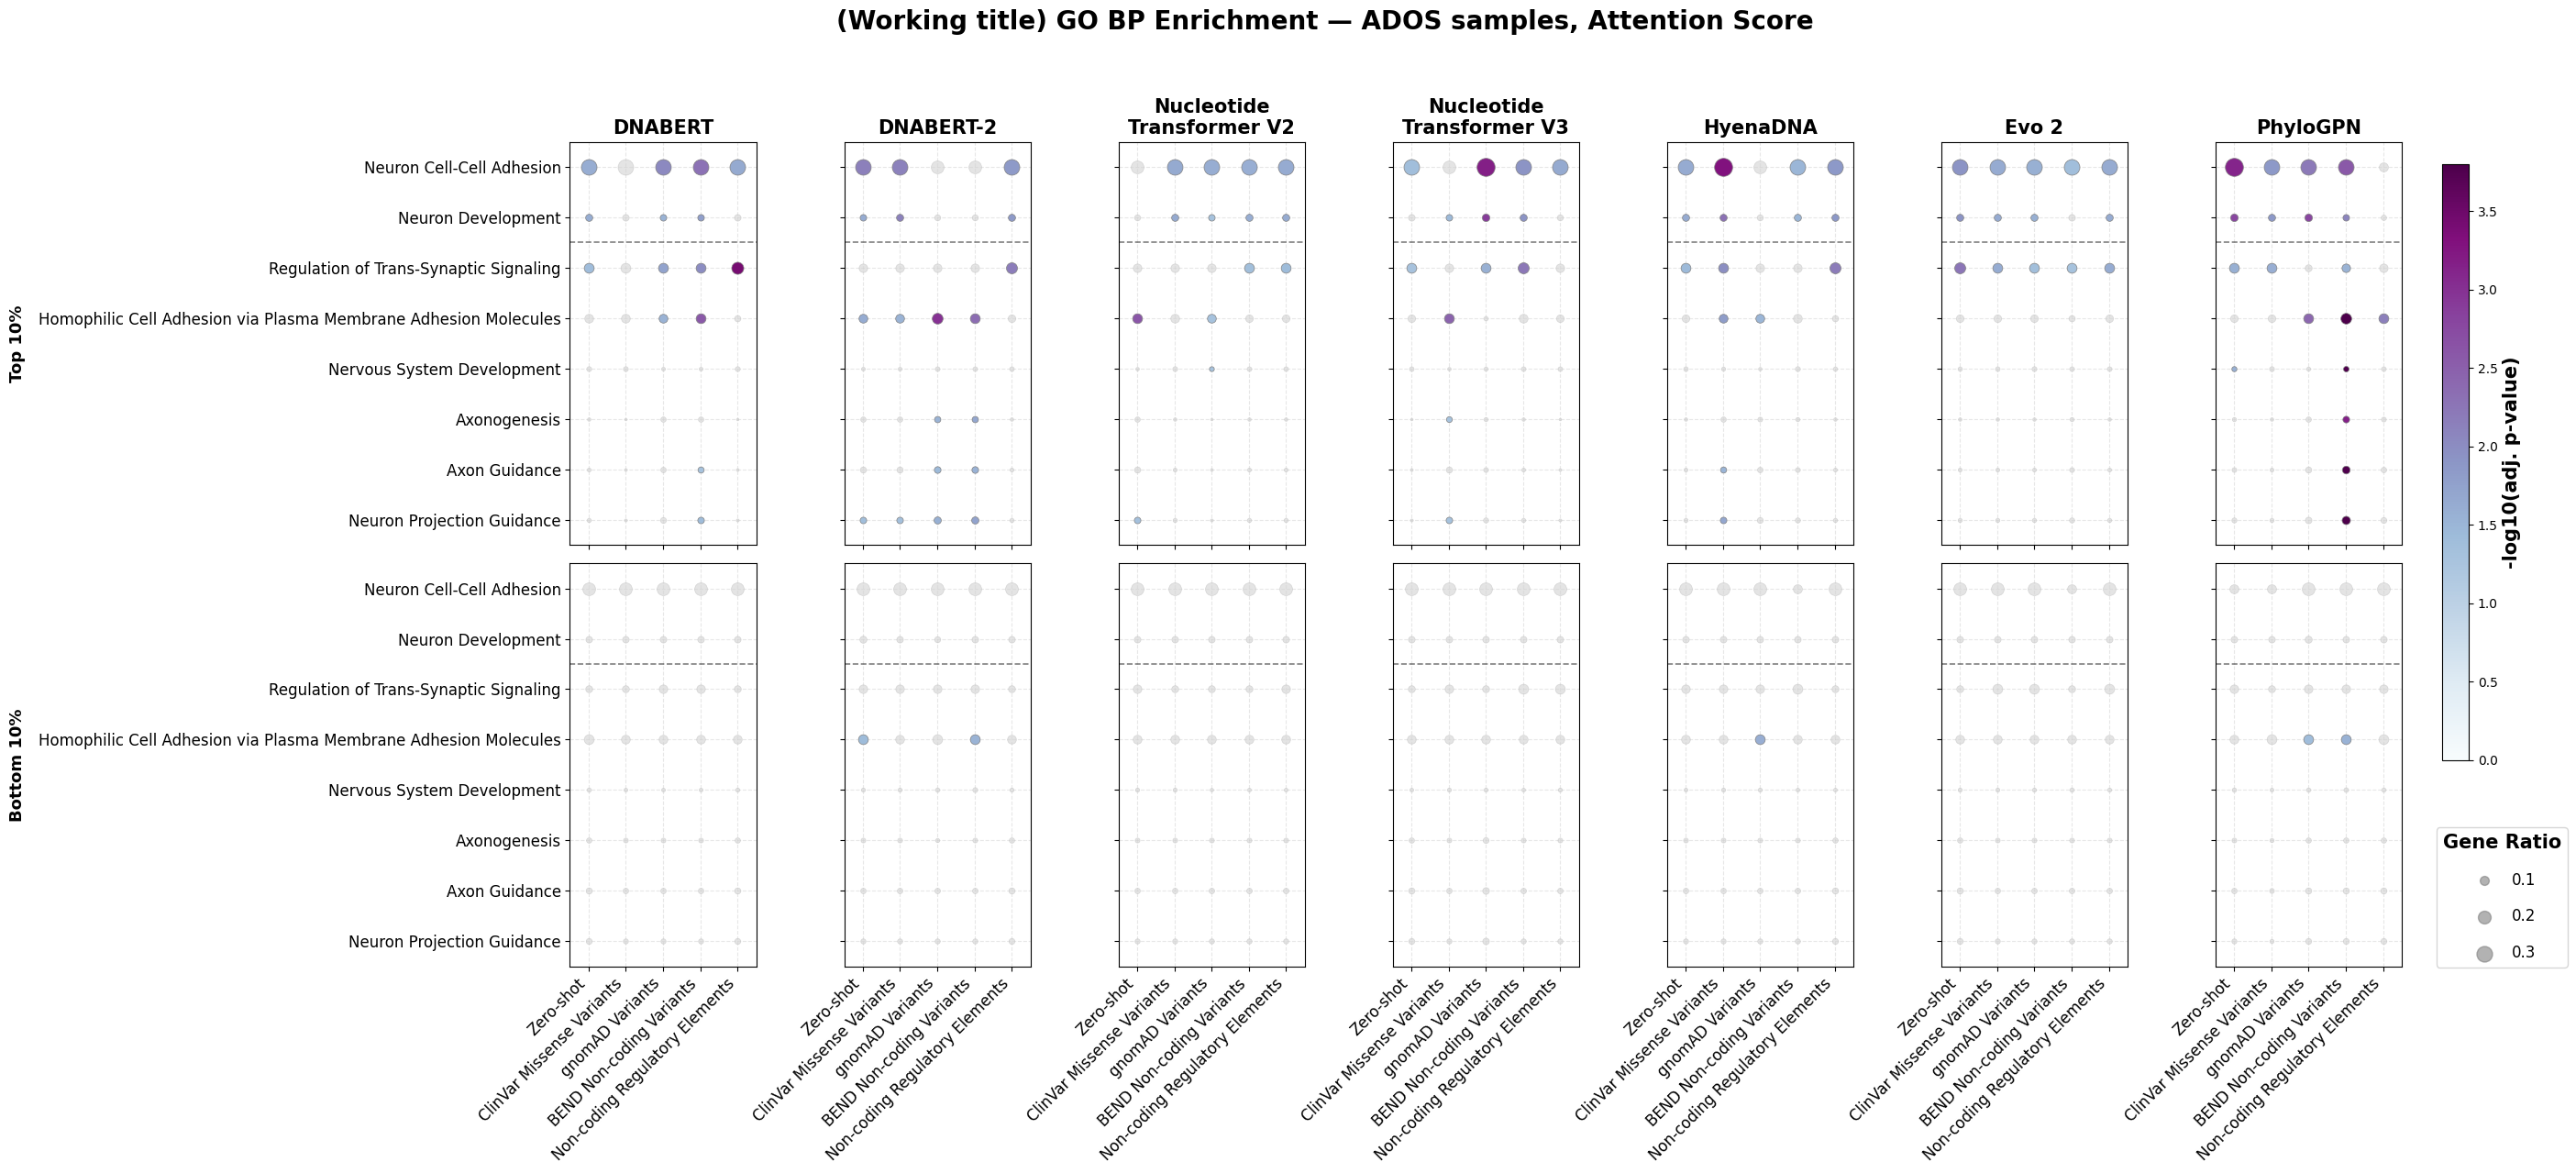

In [24]:
all_logp = []
for model in models:
    for task in tasks:
        key = f"{model}_{task}"
        for results in [results_enrich_ados_high, results_enrich_ados_low]:
            if key not in results:
                continue
            df = results[key]
            for term in target_terms_ados:
                row = df[df['Term'] == term]
                if len(row) > 0 and row['Adjusted P-value'].values[0] < 0.05:
                    p = row['Adjusted P-value'].values[0]
                    all_logp.append(-np.log10(p + 1e-300))

vmin, vmax = 0, (max(all_logp) if all_logp else 1)
print(vmin)
print(vmax)

fig, axes = plt.subplots(2, 7, figsize=(29, 13), sharey=True, sharex=True)

for col, model in enumerate(models):
    for row_idx, (results, label_suffix) in enumerate([
        (results_enrich_ados_high, 'Top 10%'),
        (results_enrich_ados_low,  'Bottom 10%')
    ]):
        ax = axes[row_idx][col]

        for j, task in enumerate(tasks):
            key = f"{model}_{task}"
            if key not in results:
                continue
            df = results[key]

            for i, term in enumerate(target_terms_ados):
                row = df[df['Term'] == term]
                if len(row) == 0:
                    continue

                adj_p      = row['Adjusted P-value'].values[0]
                gene_ratio = parse_gene_ratio(row['Overlap'].values[0])
                logp       = -np.log10(adj_p + 1e-300)

                if adj_p < 0.05:
                    ax.scatter(j, i, s=gene_ratio * 700, c=logp,
                               cmap='BuPu', vmin=vmin, vmax=vmax,
                               edgecolors='grey', linewidths=0.5, zorder=3)
                else:
                    ax.scatter(j, i, s=gene_ratio * 700,
                               color='lightgrey', edgecolors='silver',
                               linewidths=0.5, alpha=0.6, zorder=2)

        ax.set_xlim(-0.5, len(tasks) - 0.5)
        ax.set_ylim(-0.5, len(target_terms_ados) - 0.5)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.axhline(y=5.5, color='black', linewidth=1.2, linestyle='--', alpha=0.5)

        if row_idx == 0:
            ax.set_title(model_labels[model], fontsize=15, fontweight='bold')

        ax.set_xticks(range(len(tasks)))
        if row_idx == 1:
            ax.set_xticklabels([task_labels[t] for t in tasks], fontsize=12, rotation=45, ha='right')
        else:
            ax.set_xticklabels([])

        ax.set_yticks(range(len(target_terms_ados)))
        if col == 0:
            ax.set_yticklabels([t.split(' (GO')[0] for t in target_terms_ados], fontsize=12)

        if col == 0:
            ax.set_ylabel(label_suffix, fontsize=13, fontweight='bold', labelpad=10)

cbar_ax = fig.add_axes([0.92, 0.35, 0.01, 0.5])
sm = plt.cm.ScalarMappable(cmap='BuPu', norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('-log10(adj. p-value)', fontsize=15, fontweight='bold')

legend_ratios = [0.1, 0.2, 0.3]
legend_handles = [plt.scatter([], [], s=r*500, c='grey', alpha=0.6, label=f'{r:.1f}') for r in legend_ratios]

leg = fig.legend(handles=legend_handles, title='Gene Ratio', loc='lower right',
                 bbox_to_anchor=(0.97, 0.17), fontsize=12, title_fontsize=15,
                 frameon=True, labelspacing=1.3)
leg.get_title().set_fontweight('bold')

fig.suptitle('(Working title) GO BP Enrichment — ADOS samples, Attention Score',
             fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.91, 0.95])
plt.show()

# VABS

## filtering

In [25]:
# ── VABS severe samples (<70) ───────────────────────────────
vabs_valid = sev_filtered[sev_filtered['VABS'].notna()].copy()
vabs_top_samples = set(vabs_valid[vabs_valid['VABS'] < 70]['vcf_iid'])
print(f"# VABS severe samples: {len(vabs_top_samples)}")

# VABS severe samples: 235


In [26]:
gene_list_dict_attn_high_in_vabs = {}
gene_list_dict_attn_low_in_vabs  = {}

for model, task_dict in model_tasks_attn.items():
    for task, attn_df in task_dict.items():
        col_name = f"{model}_{task}"

        attn_sev = attn_df[attn_df['vcf_iid'].astype(str).isin(vabs_top_samples)].copy()
        attn_sev['vcf_iid'] = attn_sev['vcf_iid'].astype(str)

        attn_clr = clr_transform_by_sample(attn_sev)

        n_top = int(np.ceil(len(attn_clr) * TOP_FRAC))
        high = attn_clr.nlargest(n_top, CLR_COL)
        low  = attn_clr.nsmallest(n_top, CLR_COL)

        high_gene = high.merge(dnv_gene, on=['vcf_iid', 'variant'], how='inner')
        low_gene  = low.merge(dnv_gene,  on=['vcf_iid', 'variant'], how='inner')

        def get_recurrent_genes(df):
            variant_cnt = (
                df.groupby('gene_symbol')['variant']
                .nunique()
                .reset_index()
                .rename(columns={'variant': 'variant_cnt'})
            )
            sample_cnt = (
                df.groupby('gene_symbol')['vcf_iid']
                .nunique()
                .reset_index()
                .rename(columns={'vcf_iid': 'sample_cnt'})
            )
            merged = variant_cnt.merge(sample_cnt, on='gene_symbol')
            return merged[
                (merged['variant_cnt'] >= 2) & (merged['sample_cnt'] >= 2)
            ]['gene_symbol'].tolist()

        gene_list_dict_attn_high_in_vabs[col_name] = get_recurrent_genes(high_gene)
        gene_list_dict_attn_low_in_vabs[col_name]  = get_recurrent_genes(low_gene)

        print(f"{col_name:<22} attn_high={len(gene_list_dict_attn_high_in_vabs[col_name]):>4} | "
              f"attn_low={len(gene_list_dict_attn_low_in_vabs[col_name]):>4}")

/tmp/ipykernel_54837/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


DNABERT_ZS             attn_high=  51 | attn_low= 104


/tmp/ipykernel_54837/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


DNABERT_NCRE           attn_high=  50 | attn_low=  89


/tmp/ipykernel_54837/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


...

PhyloGPN_BEND          attn_high=  47 | attn_low= 117


/tmp/ipykernel_54837/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


PhyloGPN_ClinVar       attn_high=  51 | attn_low=  94


/tmp/ipykernel_54837/2741368679.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("vcf_iid", group_keys=False).apply(_clr)


PhyloGPN_gnomAD        attn_high=  48 | attn_low= 121


## GSEApy Enrichr

In [27]:
results_enrich_vabs_high = {}
results_enrich_vabs_low  = {}

for col_name, genes in gene_list_dict_attn_high_in_vabs.items():
    if len(genes) == 0:
        print(f"{col_name}: None gene list, skip")
        continue
    try:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets='GO_Biological_Process_2025',
            organism='human',
            outdir=None,
            verbose=False
        )
        results_enrich_vabs_high[col_name] = enr.results
        print(f"{col_name}: success, ({len(genes)} gene)")
    except Exception as e:
        print(f"{col_name}: failure → {e}")

for col_name, genes in gene_list_dict_attn_low_in_vabs.items():
    if len(genes) == 0:
        print(f"{col_name}: None gene list, skip")
        continue
    try:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets='GO_Biological_Process_2025',
            organism='human',
            outdir=None,
            verbose=False
        )
        results_enrich_vabs_low[col_name] = enr.results
        print(f"{col_name}: success, ({len(genes)} gene)")
    except Exception as e:
        print(f"{col_name}: failure → {e}")

DNABERT_ZS: success, (51 gene)
DNABERT_NCRE: success, (50 gene)
DNABERT_BEND: success, (47 gene)
DNABERT_ClinVar: success, (56 gene)
DNABERT_gnomAD: success, (51 gene)
DNABERT2_ZS: success, (51 gene)
DNABERT2_NCRE: success, (52 gene)
DNABERT2_BEND: success, (49 gene)
DNABERT2_ClinVar: success, (47 gene)
DNABERT2_gnomAD: success, (63 gene)
NTv2_ZS: success, (47 gene)
NTv2_NCRE: success, (51 gene)
NTv2_BEND: success, (53 gene)
NTv2_ClinVar: success, (52 gene)
NTv2_gnomAD: success, (58 gene)
NTv3_ZS: success, (50 gene)
NTv3_NCRE: success, (61 gene)
NTv3_BEND: success, (51 gene)
NTv3_ClinVar: success, (49 gene)
NTv3_gnomAD: success, (51 gene)
HyenaDNA_ZS: success, (51 gene)
HyenaDNA_NCRE: success, (52 gene)
HyenaDNA_BEND: success, (52 gene)
HyenaDNA_ClinVar: success, (48 gene)
HyenaDNA_gnomAD: success, (49 gene)
Evo 2_ZS: success, (55 gene)
Evo 2_NCRE: success, (51 gene)
Evo 2_BEND: success, (52 gene)
Evo 2_ClinVar: success, (51 gene)
Evo 2_gnomAD: success, (57 gene)
PhyloGPN_ZS: success, 

## Visualization

In [28]:
tasks = ['ZS', 'ClinVar', 'gnomAD', 'BEND', 'NCRE'] 

target_terms_vabs = [
    # ── circuit ──────────────────────────────────────────────                            
    'Neuron Projection Guidance (GO:0097485)',                                            
    'Axon Guidance (GO:0007411)',                                                         
    'Axonogenesis (GO:0007409)',                                                          
    'Nervous System Development (GO:0007399)',                                             
    # ── synapse / signaling ───────────────────────────────────
    'Homophilic Cell Adhesion via Plasma Membrane Adhesion Molecules (GO:0007156)',    
    'Regulation of Trans-Synaptic Signaling (GO:0099177)',
    # VABS specific
    # ── Calcium (VABS-specific highlight) ──────────
    'Calcium Ion Transport (GO:0006816)',
    'Calcium Ion Transmembrane Transport (GO:0070588)',
    'Regulation of Cytosolic Calcium Ion Concentration (GO:0051480)',
    'Positive Regulation of Calcium Ion Transmembrane Transport (GO:1904427)',
    # ── Cell Polarity / Structural ────────────────────────────
    'Establishment of Centrosome Localization (GO:0051660)',
    'Establishment or Maintenance of Apical/Basal Cell Polarity (GO:0035088)',
    'Protein Localization to Plasma Membrane (GO:0072659)',
]

0
3.976355697203697


/tmp/ipykernel_54837/2810680879.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.95])


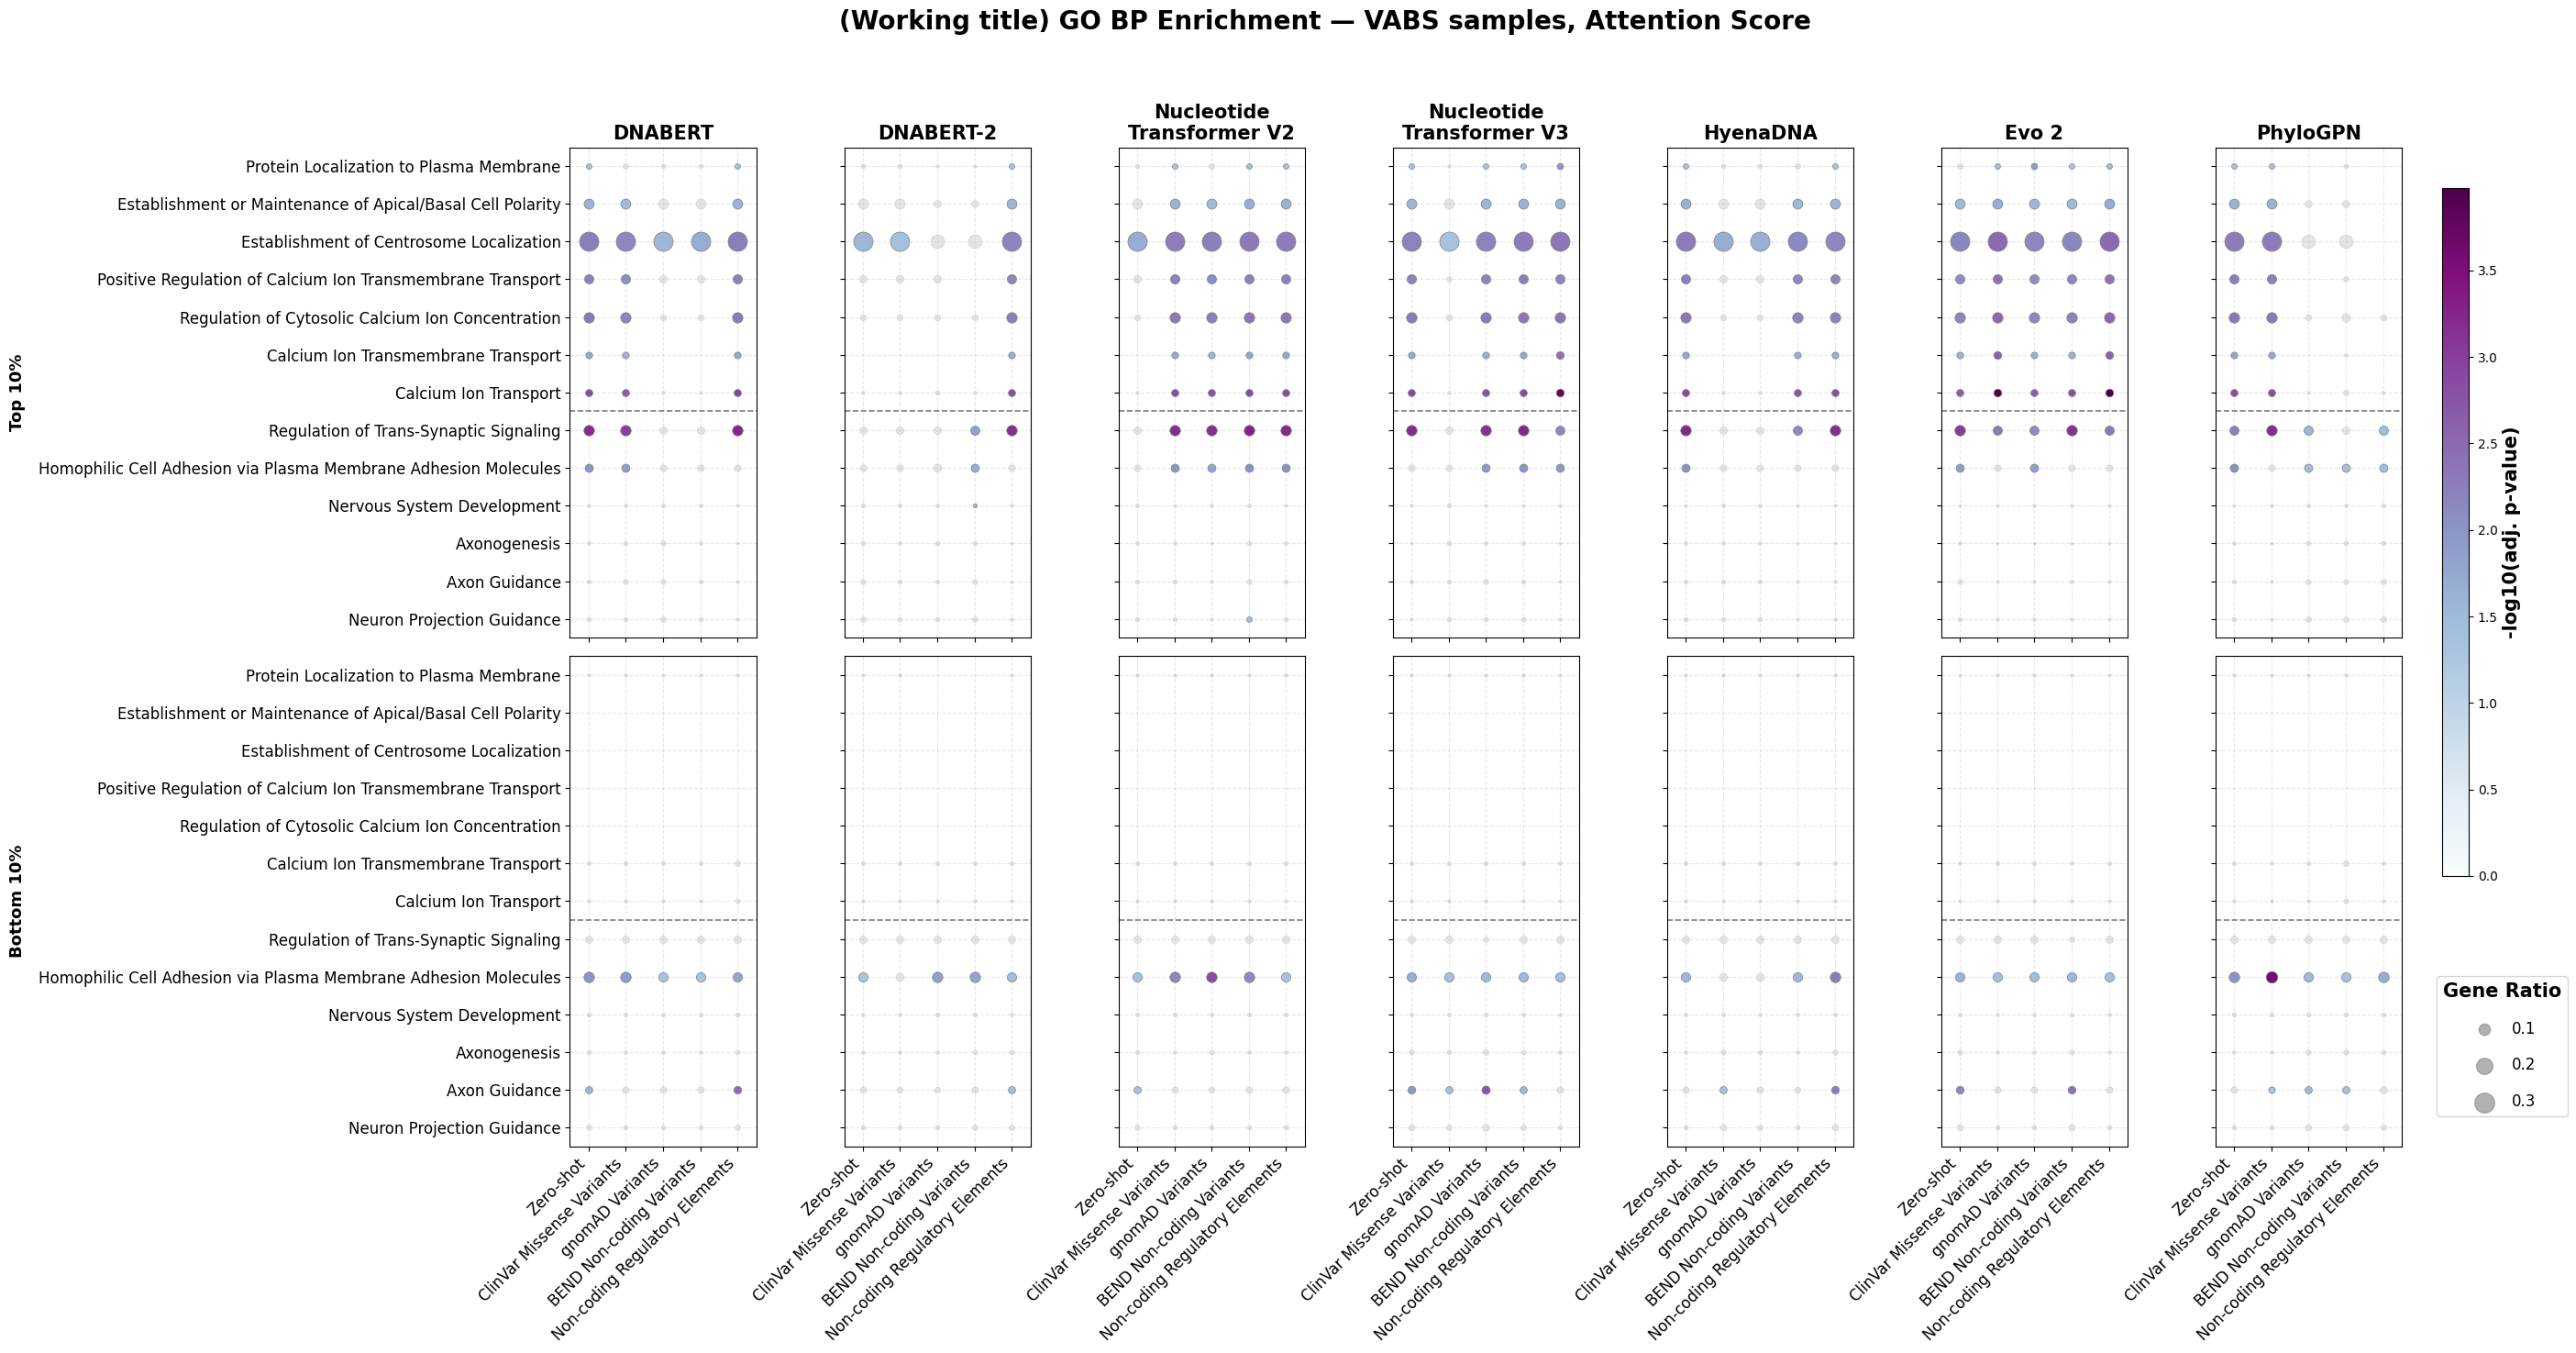

In [29]:
# ── color scale 통일 ──────────────────────────────────────────
all_logp = []
for model in models:
    for task in tasks:
        key = f"{model}_{task}"
        for results in [results_enrich_vabs_high, results_enrich_vabs_low]:
            if key not in results:
                continue
            df = results[key]
            for term in target_terms_vabs:
                row = df[df['Term'] == term]
                if len(row) > 0 and row['Adjusted P-value'].values[0] < 0.05:
                    p = row['Adjusted P-value'].values[0]
                    all_logp.append(-np.log10(p + 1e-300))

vmin, vmax = 0, (max(all_logp) if all_logp else 1)
print(vmin)
print(vmax)

fig, axes = plt.subplots(2, 7, figsize=(29, 15), sharey=True, sharex=True)

for col, model in enumerate(models):
    for row_idx, (results, label_suffix) in enumerate([
        (results_enrich_vabs_high, 'Top 10%'),
        (results_enrich_vabs_low,  'Bottom 10%')
    ]):
        ax = axes[row_idx][col]

        for j, task in enumerate(tasks):
            key = f"{model}_{task}"
            if key not in results:
                continue
            df = results[key]

            for i, term in enumerate(target_terms_vabs):
                row = df[df['Term'] == term]
                if len(row) == 0:
                    continue

                adj_p      = row['Adjusted P-value'].values[0]
                gene_ratio = parse_gene_ratio(row['Overlap'].values[0])
                logp       = -np.log10(adj_p + 1e-300)

                if adj_p < 0.05:
                    ax.scatter(j, i, s=gene_ratio * 800, c=logp,
                               cmap='BuPu', vmin=vmin, vmax=vmax,
                               edgecolors='grey', linewidths=0.5, zorder=3)
                else:
                    ax.scatter(j, i, s=gene_ratio * 800,
                               color='lightgrey', edgecolors='silver',
                               linewidths=0.5, alpha=0.6, zorder=2)

        ax.set_xlim(-0.5, len(tasks) - 0.5)
        ax.set_ylim(-0.5, len(target_terms_vabs) - 0.5)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.axhline(y=5.5, color='black', linewidth=1.2, linestyle='--', alpha=0.5)

        if row_idx == 0:
            ax.set_title(model_labels[model], fontsize=15, fontweight='bold')

        ax.set_xticks(range(len(tasks)))
        if row_idx == 1:
            ax.set_xticklabels([task_labels[t] for t in tasks], fontsize=12, rotation=45, ha='right')
        else:
            ax.set_xticklabels([])

        ax.set_yticks(range(len(target_terms_vabs)))
        if col == 0:
            ax.set_yticklabels([t.split(' (GO')[0] for t in target_terms_vabs], fontsize=12)

        if col == 0:
            ax.set_ylabel(label_suffix, fontsize=13, fontweight='bold', labelpad=10)

cbar_ax = fig.add_axes([0.92, 0.35, 0.01, 0.5])
sm = plt.cm.ScalarMappable(cmap='BuPu', norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('-log10(adj. p-value)', fontsize=15, fontweight='bold')

legend_ratios = [0.1, 0.2, 0.3]
legend_handles = [plt.scatter([], [], s=r*800, c='grey', alpha=0.6, label=f'{r:.1f}') for r in legend_ratios]

leg = fig.legend(handles=legend_handles, title='Gene Ratio', loc='lower right',
                 bbox_to_anchor=(0.97, 0.17), fontsize=12, title_fontsize=15,
                 frameon=True, labelspacing=1.3)
leg.get_title().set_fontweight('bold')

fig.suptitle('(Working title) GO BP Enrichment — VABS samples, Attention Score',
             fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.91, 0.95])
plt.show()